In [1]:
import torch 
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# device = 'mps' if torch.mps.is_available() else 'cpu'
device = 'cpu'
torch.mps.manual_seed(1234)
torch.manual_seed(1234)

In [2]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
    n_samples =5000, n_features=NUM_FEATURES, 
    centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
X_train, X_test, y_train, y_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED
)

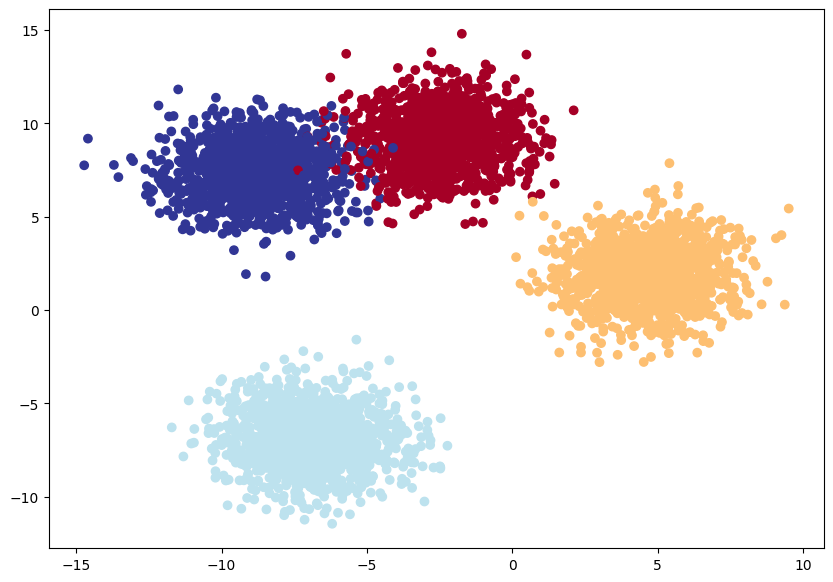

In [3]:
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.show()

In [4]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [5]:
class BobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.layer_1 = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_1(x)

bobmodel0 = BobModel(NUM_FEATURES, NUM_CLASSES).to(device=device)

In [6]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(bobmodel0.parameters(), lr=0.1)

In [7]:
y_logits = bobmodel0(X_train.to(device))
y_probs = torch.softmax(y_logits, dim=1)

In [8]:
def accuracy_function(y_pred, y_true):
    # 1. Force both to CPU to prevent device crashes
    # 2. Flatten them to guarantee they are 1D lists (destroys hidden dimensions)
    # 3. Cast to .long() to guarantee they are both 64-bit integers
    y_pred_clean = y_pred.cpu().flatten().long()
    y_true_clean = y_true.cpu().flatten().long()
    
    # 4. Use standard == instead of torch.eq
    # 5. Convert the True/False mask to 1.0s and 0.0s, and take the average
    acc = (y_pred_clean == y_true_clean).float().mean().item() * 100
    
    return acc

In [9]:
total_epos = 100
test_losses, train_losses, epochs, test_accs, train_accs = [], [], [], [], []

for i in range(total_epos):
    bobmodel0.train()
    train_logits = bobmodel0(X_train)
    train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)
    train_loss = loss_function(train_logits, y_train)
    train_acc = accuracy_function(train_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    bobmodel0.eval()
    with torch.inference_mode():
        test_logits = bobmodel0(X_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_function(test_logits, y_test)
        test_acc = accuracy_function(test_pred, y_test)

        train_losses.append(train_loss.item())
        epochs.append(i)
        test_losses.append(test_loss.item())
        test_accs.append(test_acc)
        train_accs.append(train_acc)
        if i == 0:
            print(f"pred: {train_pred[:10]}")
            print(f"true: {y_train[:10]}")
            print(f"equal: {(train_pred == y_train)[:10]}")
        if i % 10 == 0:
            print(f'Epoch {i} | Train Acc: {train_acc} | Test Acc: {test_acc}')

pred: tensor([1, 0, 1, 2, 2, 0, 1, 1, 0, 1])
true: tensor([2, 1, 2, 0, 0, 1, 2, 3, 1, 2])
equal: tensor([False, False, False, False, False, False, False, False, False, False])
Epoch 0 | Train Acc: 0.0 | Test Acc: 55.09999990463257
Epoch 10 | Train Acc: 98.35000038146973 | Test Acc: 98.4000027179718
Epoch 20 | Train Acc: 98.87499809265137 | Test Acc: 98.69999885559082
Epoch 30 | Train Acc: 98.92500042915344 | Test Acc: 98.90000224113464
Epoch 40 | Train Acc: 99.00000095367432 | Test Acc: 98.7999975681305
Epoch 50 | Train Acc: 98.97500276565552 | Test Acc: 98.7999975681305
Epoch 60 | Train Acc: 99.00000095367432 | Test Acc: 98.7999975681305
Epoch 70 | Train Acc: 99.00000095367432 | Test Acc: 98.69999885559082
Epoch 80 | Train Acc: 99.00000095367432 | Test Acc: 98.69999885559082
Epoch 90 | Train Acc: 99.00000095367432 | Test Acc: 98.69999885559082


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_decision_boundary(model, X, y):
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
    
    model.eval()
    with torch.inference_mode():
        logits = model(X_to_pred_on)
        y_pred = torch.softmax(logits, dim=1).argmax(dim=1)

    y_pred = y_pred.reshape(xx.shape).detach().numpy()

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Multi-Class Decision Boundary")
    plt.show()
    
    model.to(device)

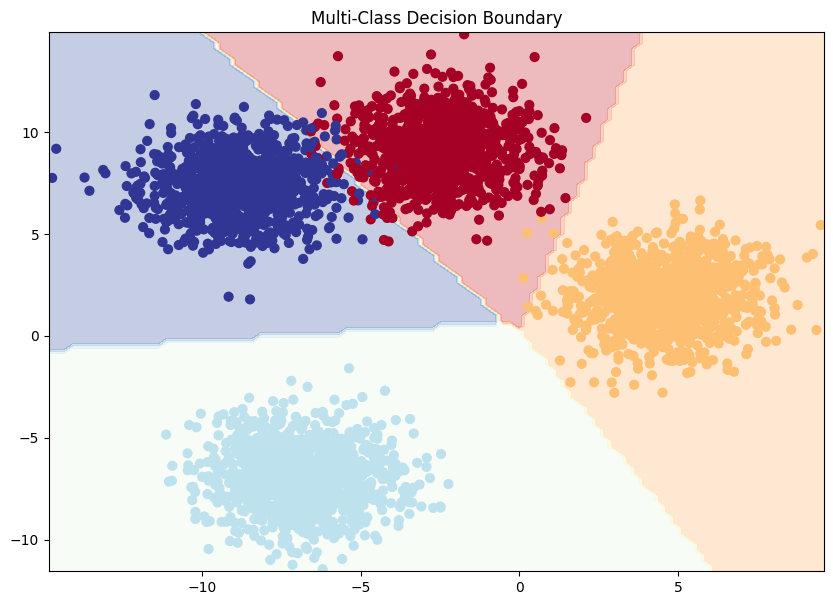

In [13]:
plot_decision_boundary(bobmodel0, X_train, y_train)

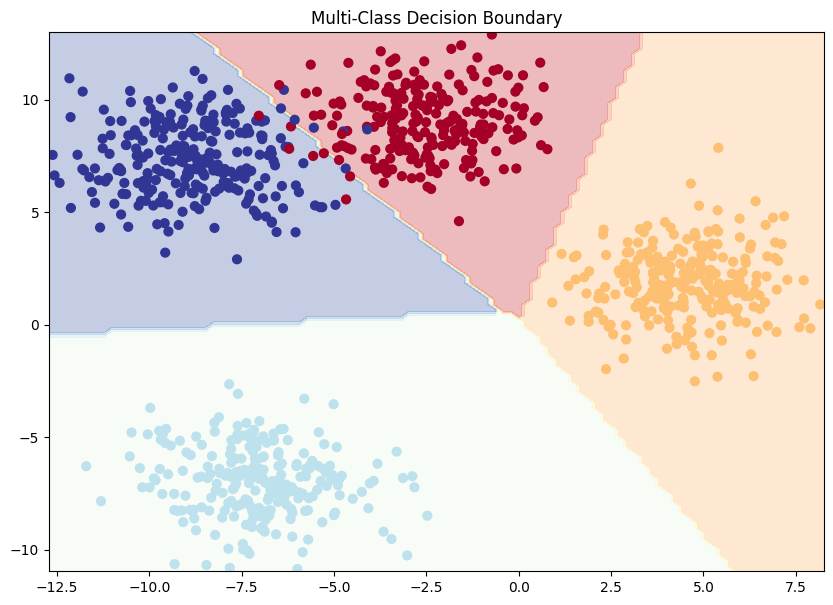

In [14]:
plot_decision_boundary(bobmodel0, X_test, y_test)